In [1]:
!pip install google-play-scraper


from google_play_scraper import app
import pandas as pd
import numpy as np


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.1 MB/s eta 0:00:00


In [2]:
# Mengambil ulasan sesuai jumlah yang diinginkan


from google_play_scraper import Sort, reviews


result, continuation_token = reviews(
    'com.kurogame.wutheringwaves.global',
    lang='id', # Mengumpulkan komentar dengan bahasa Indonesia
    country='id', # Mengumpulkan data pada region Indonesia
    sort=Sort.NEWEST, # Sort.NEWEST digunakan untuk mendapatkan ulasan terbaru
    count=2000, # Mengumpulkan data sebanyak 2000 komentar
    filter_score_with=None # defaultnya adalah None (artinya semua skor). Gunakan 1, 2, 3, 4, atau 5 untuk memfilter skor tertentu
)


In [3]:
import pandas as pd

# Membuat DataFrame dari result
df = pd.DataFrame(result)

# Pilih kolom yang dibutuhkan
new_df = df[['userName', 'score', 'at', 'content']]

# Urutkan berdasarkan tanggal terbaru
sorted_df = new_df.sort_values(by='at', ascending=False)

# Tampilkan 5 data pertama
sorted_df.head()

# Simpan ke file CSV
sorted_df.to_csv("scrapped_data_wuwa.csv", index=False)


In [4]:
import string
from sklearn.pipeline import Pipeline
import re
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import numbers
from pandas.io.excel import ExcelWriter
import numpy as np


In [5]:
# Baca file CSV hasil scrapping
data = pd.read_csv("scrapped_data_wuwa.csv")

# Konversi kolom 'at' ke datetime
data['at'] = pd.to_datetime(data['at'])

# Filter tanggal 12 Juni 2025 hingga 26 Agustus 2025
start_date = '2025-06-12'
end_date   = '2025-08-25'
data = data.loc[(data['at'] >= start_date) & (data['at'] <= end_date)].copy()

# Terapkan casefold pada kolom 'content'
data['content'] = data['content'].apply(lambda x: str(x).casefold())

# Simpan hasil ke file Excel
output_filename = 'filtered_data_wuwa.xlsx'
data.to_excel(output_filename, index=False)

# Tampilkan data
display(data.head(10))


,userName,score,at,content
20,Infinix X6812B,5,2025-08-24 22:17:51,tolong tambahkan bahasa indonesia 🙏
21,Imam Al-hafiz,5,2025-08-24 22:03:22,awesome
22,Hafith Ryan,5,2025-08-24 19:54:32,mantap
23,Zed Zero,5,2025-08-24 19:23:07,i love kurogames
24,Muhammad Fathi Rafa,5,2025-08-24 18:27:17,"game yang sangat bagus, dan maaf review sebelu..."
25,Ardhika Dwi,5,2025-08-24 16:08:18,absolute cinema
26,Rifxi Kurniawan,5,2025-08-24 16:02:35,mantullll
27,シャロンMirabilis,5,2025-08-24 14:44:36,baik banget jirr
28,Ibnu Kharis,3,2025-08-24 14:33:22,nice experience but i didn't get the 70++ free...
29,Afi,5,2025-08-24 13:20:44,gamedev the best selalu dengerin pemainnya


In [6]:
import re
import string
import nltk

# Fungsi untuk menghapus URL
def remove_URL(tweet):
    if tweet is not None and isinstance(tweet, str):
        url = re.compile(r'https?://\S+|www\.\S+')
        return url.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus HTML
def remove_html(tweet):
    if tweet is not None and isinstance(tweet, str):
        html = re.compile(r'<.*?>')
        return html.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus emoji
def remove_emoji(tweet):
    if tweet is not None and isinstance(tweet, str):
        emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F700-\U0001F77F"  # alchemical symbols
                               u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
                               u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
                               u"\U0001FA00-\U0001FA6F"  # Chess Symbols
                               u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
                               u"\U0001F004-\U0001F0CF"  # Additional emoticons
                               u"\U0001F1E0-\U0001F1FF"  # flags
                               "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus simbol
def remove_symbols(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'[^a-zA-Z0-9\s]', '', tweet) # Menghapus semua simbol
        return tweet

# Fungsi untuk menghapus angka
def remove_numbers(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'\d', '', tweet) # Menghapus semua angka
        return tweet

def remove_username(text):
    import re
    return re.sub(r'@[^\s]+', '', text)

data['cleaning'] = data['content'].apply(lambda x: remove_URL(x))
data['cleaning'] = data['cleaning'].apply(lambda x: remove_username(x))
data['cleaning'] = data['cleaning'].apply(lambda x: remove_html(x))
data['cleaning'] = data['cleaning'].apply(lambda x: remove_emoji(x))
data['cleaning'] = data['cleaning'].apply(lambda x: remove_symbols(x))
data['cleaning'] = data['cleaning'].apply(lambda x: remove_numbers(x))

data.head(5)

,userName,score,at,content,cleaning
20,Infinix X6812B,5,2025-08-24 22:17:51,tolong tambahkan bahasa indonesia 🙏,tolong tambahkan bahasa indonesia
21,Imam Al-hafiz,5,2025-08-24 22:03:22,awesome,awesome
22,Hafith Ryan,5,2025-08-24 19:54:32,mantap,mantap
23,Zed Zero,5,2025-08-24 19:23:07,i love kurogames,i love kurogames
24,Muhammad Fathi Rafa,5,2025-08-24 18:27:17,"game yang sangat bagus, dan maaf review sebelu...",game yang sangat bagus dan maaf review sebelum...


In [7]:
!pip install sastrawi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.5 MB/s eta 0:00:00


In [8]:
# Mengimpor Pustaka
import pandas as pd
import re
import numpy as np
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
import string


# Konfigurasi
dataset_filename = 'filtered_data_wuwa.xlsx'  # <- File Excel
alay_dict_filename = 'Kamus-Alay.csv'
text_column = 'content'  # Kolom berisi ulasan


# 1. Load Dataset
try:
    data = pd.read_excel(dataset_filename)  # Ganti read_csv -> read_excel
    print(f" Dataset '{dataset_filename}' loaded successfully.")
except FileNotFoundError:
    print(f" Error: Dataset file '{dataset_filename}' not found.")
    exit()


# 2. Load Kamus Alay
try:
    # Baca file CSV tanpa asumsi jumlah kolom
    kamus_alay_df = pd.read_csv(alay_dict_filename, sep=None, engine="python")

    # Ambil hanya 2 kolom pertama (alay dan baku)
    kamus_alay_df = kamus_alay_df.iloc[:, :2]
    kamus_alay_df.columns = ['alay', 'baku']

    # Buat dictionary
    alay_dict = dict(zip(kamus_alay_df['alay'], kamus_alay_df['baku'].dropna()))
    print(f" Alay dictionary '{alay_dict_filename}' loaded successfully.")

except FileNotFoundError:
    print(f" Error: Alay dictionary file '{alay_dict_filename}' not found.")
    alay_dict = {}   # biar gak error, bikin kamus kosong
except Exception as e:
    print(f" An error occurred while loading the alay dictionary: {e}")
    alay_dict = {}   # fallback supaya tetap jalan




# 3. Preprocessing Function
def casefolding(description):
    description = str(description).lower()
    description = description.strip()
    description = re.sub(r'http\S+|www\S+', '', description)
    description = re.sub(r'[^a-zA-Z0-9\s]', '', description)
    description = re.sub(r'\d+', '', description)
    return description


def tokenize_text(text):
    return re.findall(r'\b\w+\b', str(text).lower())


factory_stopword = StopWordRemoverFactory()
stopword_remover = factory_stopword.create_stop_word_remover()
def remove_stopwords(tokens):
    if not isinstance(tokens, list):
        return []
    return [stopword_remover.remove(token) for token in tokens if stopword_remover.remove(token) != '']


factory_stemmer = StemmerFactory()
stemmer = factory_stemmer.create_stemmer()
def stem_tokens(tokens):
    if not isinstance(tokens, list):
        return []
    return [stemmer.stem(token) for token in tokens]


def normalize_tokens(tokens, alay_dict):
    if not isinstance(tokens, list):
        return []
    return [alay_dict.get(token, token) for token in tokens if pd.notna(token)]


# 4. Menerapkan tahapan Preprocessing
print("\n Applying preprocessing steps...")


data['casefolded_content'] = data[text_column].apply(casefolding)
print("Casefolding applied.")


data['tokens'] = data['casefolded_content'].apply(tokenize_text)
print("Tokenization applied.")


data['tokens_no_stopwords'] = data['tokens'].apply(remove_stopwords)
print("Stopword removal applied.")


data['stemmed_tokens'] = data['tokens_no_stopwords'].apply(stem_tokens)
print("Stemming applied.")


data['normalized_tokens'] = data['stemmed_tokens'].apply(lambda tokens: normalize_tokens(tokens, alay_dict))
print("Normalization applied.")


data['normalized_text'] = data['normalized_tokens'].apply(lambda tokens: ' '.join(tokens))
print("Normalized text column created.")


# 5. Mengekspor dalam bentuk Excel
output_filename = 'preprocessed_wuwa_filtered.xlsx'
columns_to_export = ['userName', 'score', 'content', 'at', 'normalized_text']
try:
    data[columns_to_export].to_excel(output_filename, index=False, engine='openpyxl')
    print(f"\n File Excel berhasil disimpan sebagai '{output_filename}'.")
except Exception as e:
    print(f"Terjadi kesalahan saat menyimpan file Excel: {e}")


# 6. Menampilkan sampel
print("\n Preview of processed data:")
display(data[columns_to_export].head())


 Dataset 'filtered_data_wuwa.xlsx' loaded successfully.
 Alay dictionary 'Kamus-Alay.csv' loaded successfully.

 Applying preprocessing steps...
Casefolding applied.
Tokenization applied.
Stopword removal applied.
Stemming applied.
Normalization applied.
Normalized text column created.

 File Excel berhasil disimpan sebagai 'preprocessed_wuwa_filtered.xlsx'.

 Preview of processed data:


,userName,score,content,at,normalized_text
0,Infinix X6812B,5,tolong tambahkan bahasa indonesia 🙏,2025-08-24 22:17:51,tambah bahasa indonesia
1,Imam Al-hafiz,5,awesome,2025-08-24 22:03:22,awesome
2,Hafith Ryan,5,mantap,2025-08-24 19:54:32,mantap
3,Zed Zero,5,i love kurogames,2025-08-24 19:23:07,i love kurogames
4,Muhammad Fathi Rafa,5,"game yang sangat bagus, dan maaf review sebelu...",2025-08-24 18:27:17,game sangat bagus maaf review nya


In [9]:
import torch


# Memeriksa ketersediaan GPU
if torch.cuda.is_available():
  device = torch.device('cuda')


  print('Terdapat %d GPU yang tersedia.' % torch.cuda.device_count())


  print('Kita akan menggunakan GPU: ', torch.cuda.get_device_name(0))


else:
  print("Tidak ada GPU tersedia, menggunakan CPU sebagai gantinya")
  device = torch.device("cpu")


# Menginstal library transformers
!pip install transformers


Tidak ada GPU tersedia, menggunakan CPU sebagai gantinya


In [10]:
import pandas as pd
import os


# Mencetak direktori kerja saat ini
print("Direktori kerja saat ini:", os.getcwd())


# Mendefinisikan path file
excel_file_path = './preprocessed_wuwa_filtered.xlsx'


# Memeriksa apakah file ada
if os.path.exists(excel_file_path):
    print(f"Memuat dataset dari {excel_file_path}...")
    df = pd.read_excel(excel_file_path)


    # Menampilkan beberapa baris pertama
    display(df.head())


    # Membuat kolom baru untuk label sentimen
    def label_sentimen(score):
        if score == 1:
            return 'Sangat Negatif'
        elif score == 2:
            return 'Negatif'
        elif score == 3:
            return 'Netral'
        elif score == 4:
            return 'Positif'
        elif score == 5:
            return 'Sangat Positif'
        else:
            return 'Tidak Valid'


    df['sentimen'] = df['score'].apply(label_sentimen)


    # Membuat DataFrame terpisah untuk masing-masing kategori
    df_sangat_negatif = df[df['sentimen'] == 'Sangat Negatif']
    df_negatif = df[df['sentimen'] == 'Negatif']
    df_netral = df[df['sentimen'] == 'Netral']
    df_positif = df[df['sentimen'] == 'Positif']
    df_sangat_positif = df[df['sentimen'] == 'Sangat Positif']
# Menampilkan jumlah data pada setiap kategori
    print("Jumlah data per kategori sentimen:")
    print(f"Sangat Negatif   : {df_sangat_negatif.shape[0]}")
    print(f"Negatif          : {df_negatif.shape[0]}")
    print(f"Netral           : {df_netral.shape[0]}")
    print(f"Positif          : {df_positif.shape[0]}")
    print(f"Sangat Positif   : {df_sangat_positif.shape[0]}")


else:
    print(f"Error: File dataset '{excel_file_path}' tidak ditemukan.")
    print("Pastikan file dataset sudah diunggah ke direktori saat ini.")
    df = None


Direktori kerja saat ini: /content
Memuat dataset dari ./preprocessed_wuwa_filtered.xlsx...


,userName,score,content,at,normalized_text
0,Infinix X6812B,5,tolong tambahkan bahasa indonesia 🙏,2025-08-24 22:17:51,tambah bahasa indonesia
1,Imam Al-hafiz,5,awesome,2025-08-24 22:03:22,awesome
2,Hafith Ryan,5,mantap,2025-08-24 19:54:32,mantap
3,Zed Zero,5,i love kurogames,2025-08-24 19:23:07,i love kurogames
4,Muhammad Fathi Rafa,5,"game yang sangat bagus, dan maaf review sebelu...",2025-08-24 18:27:17,game sangat bagus maaf review nya


Jumlah data per kategori sentimen:
Sangat Negatif   : 220
Negatif          : 61
Netral           : 112
Positif          : 147
Sangat Positif   : 1440


In [11]:
import numpy as np


# Mengasumsikan 'content' adalah kolom teks dan 'score' adalah kolom label
sentences = df.content.values
labels = df.score.values


# Mengubah rentang label dari 1-5 menjadi 0-4
labels = labels - 1
labels = labels.astype(int) # Memastikan tipe data integer

In [12]:
from transformers import BertTokenizer


print("Memuat IndoBERT Tokenizer")
# Memuat tokenizer untuk model IndoBERT (tidak peka huruf besar/kecil)
tokenizer = BertTokenizer.from_pretrained('indolem/indobert-base-uncased', do_lower_case=True)


df.sample(15)


Memuat IndoBERT Tokenizer


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

,userName,score,content,at,normalized_text,sentimen
396,ARIS SAFWAN,5,walaupun banyak yg bilang hal negatif tentang ...,2025-08-02 01:05:15,walaupun banyak yang bilang negatif lancar ini...,Sangat Positif
192,Duke Uwais al qorni,5,game bagus cuman tolong buatin subtitle indonesia,2025-08-14 03:23:28,game bagus cuman membuat subtitle indonesia,Sangat Positif
1671,Beatboxer Creative,3,tambahin text bahasa indo please cape mikir,2025-06-25 04:46:29,tambahkan text bahasa indonesia please capek m...,Netral
779,Lyuu Dzz,5,terimakasih dan saya pergi 🖐🏻🫡,2025-07-23 13:29:59,terimakasih pergi,Sangat Positif
1213,Wang YiLian王宜莲,1,game nya bagus tapi berat bgt pdhl digame lain...,2025-07-05 15:49:16,game nya bagus berat banget padahal digame yan...,Sangat Negatif
1820,grace mutiara,4,request bisa berbagi asrite dengan teman 🥲plis...,2025-06-22 06:54:56,request bagi asrite teman pliss susah banget m...,Positif
412,RIFQI SULTHON ABQARI,5,best,2025-08-01 06:58:47,best,Sangat Positif
96,Hafiz Ramadhan,5,game ini bagus banget geloooooooo,2025-08-19 06:48:39,game bagus banget geloooooooo,Sangat Positif
1111,Baka Vann,4,"semoga ditambahkan bahasa indonesia, untuk lai...",2025-07-08 06:15:24,moga tambah bahasa indonesia lain cukup baik i...,Positif
1380,ZHAVIN 02,3,kenapa setiap main selalu merah jaringannya te...,2025-07-02 04:00:27,main selalu merah jaring terus kuota kuras hab...,Netral


In [13]:
# Contoh tokenisasi pada kalimat pertama
print("Original: ", sentences[0])


print("Tokenized: ", tokenizer.tokenize(sentences[0]))


print("Token IDS: ", tokenizer.convert_tokens_to_ids(tokenizer.tokenize(sentences[0])))

# Tokenisasi semua kalimat dan tambahkan token khusus ([CLS] dan [SEP])
input_ids = []


for sent in sentences:
  encoded_sent = tokenizer.encode(
      sent,
      add_special_tokens = True # Tambahkan token [CLS] dan [SEP]
  )
  input_ids.append(encoded_sent)


print("Original: ", sentences[0])
print("Token IDs: ", input_ids[0])

# Menampilkan panjang kalimat maksimum setelah tokenisasi
print("Panjang kalimat maksimum: ", max([len(sen) for sen in input_ids]))


Original:  tolong tambahkan bahasa indonesia 🙏
Tokenized:  ['tolong', 'tambahkan', 'bahasa', 'indonesia', '[UNK]']
Token IDS:  [9917, 23959, 2097, 1718, 1]
Original:  tolong tambahkan bahasa indonesia 🙏
Token IDs:  [3, 9917, 23959, 2097, 1718, 1, 4]
Panjang kalimat maksimum:  140


In [14]:
from keras.preprocessing.sequence import pad_sequences


MAX_LEN = 64 # Menetapkan panjang maksimum untuk padding/truncating


print("Melakukan padding/truncating pada semua kalimat hingga %d nilai" % MAX_LEN)
# Menampilkan token padding dan ID-nya
print('Padding token: "{:}", ID: {:}'.format(tokenizer.pad_token, tokenizer.pad_token_id))


# Melakukan padding dan truncating pada input_ids
input_ids = pad_sequences(input_ids, maxlen=MAX_LEN, dtype='long', value=0, truncating='post', padding='post')


print("Selesai")

input_ids[0]

# Membuat attention mask untuk membedakan token asli dan token padding
attention_mask = []


for sent in input_ids:
  # Buat mask 1 untuk token > 0 (token asli) dan 0 untuk token = 0 (padding)
  att_mask = [int(token_id > 0) for token_id in sent]


  attention_mask.append(att_mask)


Melakukan padding/truncating pada semua kalimat hingga 64 nilai
Padding token: "[PAD]", ID: 0
Selesai


In [15]:
from sklearn.model_selection import train_test_split


# Membagi data menjadi training dan test set
train_input, test_input, train_labels, test_labels = train_test_split(input_ids,
            labels,
            random_state=2017,
            test_size=0.1)


# Membagi attention mask sesuai dengan pembagian data input
train_mask, test_mask, _, _ = train_test_split(attention_mask,
            labels, # Menggunakan labels untuk memastikan pembagian yang konsisten
            random_state=2017,
            test_size=0.1)


# Membagi training set lagi menjadi training dan validation set
train_input, validation_input, train_labels, validation_labels = train_test_split(train_input,
                                                                                  train_labels,
                                                                                  random_state=2018,
                                                                                  test_size=0.15)


# Membagi training mask sesuai dengan pembagian training/validation
train_mask, validation_mask, _, _ = train_test_split(train_mask,
                                                     train_mask, # Menggunakan train_mask untuk pembagian mask
            random_state=2018,
            test_size=0.15)

import numpy as np
# Menampilkan ukuran masing-masing set data
print("== Train ==")
print("Input: ", train_input.shape)
print("Label: ", train_labels.shape)
print("Mask: ", np.array(train_mask).shape)


print("\n== Validation ==")
print("Input: ", validation_input.shape)
print("Label: ", validation_labels.shape)
print("Mask: ", np.array(validation_mask).shape)


print("\n== Test ==")
print("Input: ", test_input.shape)
print("Label: ", test_labels.shape)
print("Mask: ", np.array(test_mask).shape)



== Train ==
Input:  (1514, 64)
Label:  (1514,)
Mask:  (1514, 64)

== Validation ==
Input:  (268, 64)
Label:  (268,)
Mask:  (268, 64)

== Test ==
Input:  (198, 64)
Label:  (198,)
Mask:  (198, 64)


In [16]:
import torch
# Mengubah data menjadi tensor PyTorch
train_input = torch.tensor(train_input)
train_labels = torch.tensor(train_labels)
train_mask = torch.tensor(train_mask)


validation_input = torch.tensor(validation_input)
validation_labels = torch.tensor(validation_labels)
validation_mask = torch.tensor(validation_mask)


test_input = torch.tensor(test_input)
test_labels = torch.tensor(test_labels)
test_mask = torch.tensor(test_mask)

from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler


batch_size = 32 # Menetapkan ukuran batch


# Membuat TensorDataset dan DataLoader untuk training data
train_data = TensorDataset(train_input, train_mask, train_labels)
train_sampler = RandomSampler(train_data) # Mengambil sampel data secara acak untuk training
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)


# Membuat TensorDataset dan DataLoader untuk validation data
validation_data = TensorDataset(validation_input, validation_mask, validation_labels)
validation_sampler = SequentialSampler(validation_data) # Mengambil sampel data secara berurutan untuk validation
validation_dataloader = DataLoader(validation_data, sampler=validation_sampler, batch_size=batch_size)


# Membuat TensorDataset dan DataLoader untuk test data
test_data = TensorDataset(test_input, test_mask, test_labels)
test_sampler = SequentialSampler(test_data) # Mengambil sampel data secara berurutan untuk test
test_dataloader = DataLoader(test_data, sampler=test_sampler, batch_size=batch_size)


In [17]:
from transformers import BertForSequenceClassification, BertConfig
from torch.optim import AdamW
import torch

# Load IndoBERT untuk klasifikasi
model = BertForSequenceClassification.from_pretrained(
    "indolem/indobert-base-uncased",
    num_labels=5,  # untuk skor 1–5
    output_attentions=False,
    output_hidden_states=False
)

# Pilih device otomatis (GPU kalau ada, CPU kalau tidak)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

params = list(model.named_parameters())

print("The BERT model has {:} different named parameters.".format(len(params)))

print("==== Embedding Layer ====")
for p in params[0:5]:
    print("{:<60} {:>12}".format(p[0], str(tuple(p[1].size()))))

print("==== First Transformers ====")
for p in params[5:21]:
    print("{:<60} {:>12}".format(p[0], str(tuple(p[1].size()))))

print("==== Output Layer ====")
for p in params[-4:]:
    print("{:<60} {:>12}".format(p[0], str(tuple(p[1].size()))))


pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indolem/indobert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


The BERT model has 201 different named parameters.
==== Embedding Layer ====
bert.embeddings.word_embeddings.weight                       (31923, 768)
bert.embeddings.position_embeddings.weight                     (512, 768)
bert.embeddings.token_type_embeddings.weight                     (2, 768)
bert.embeddings.LayerNorm.weight                                   (768,)
bert.embeddings.LayerNorm.bias                                     (768,)
==== First Transformers ====
bert.encoder.layer.0.attention.self.query.weight               (768, 768)
bert.encoder.layer.0.attention.self.query.bias                     (768,)
bert.encoder.layer.0.attention.self.key.weight                 (768, 768)
bert.encoder.layer.0.attention.self.key.bias                       (768,)
bert.encoder.layer.0.attention.self.value.weight               (768, 768)
bert.encoder.layer.0.attention.self.value.bias                     (768,)
bert.encoder.layer.0.attention.output.dense.weight             (768, 768)
bert.e

In [18]:
# Mendefinisikan optimizer AdamW
optimizer = AdamW(
    model.parameters(),
    lr = 2e-5, # Learning rate (tingkat pembelajaran)
    eps = 1e-8 # Epsilon untuk stabilitas numerik
)

from transformers import get_linear_schedule_with_warmup


epochs = 10 # Jumlah epoch untuk training


# Menghitung total langkah training
total_steps = len(train_dataloader) * epochs


# Mendefinisikan scheduler learning rate dengan warmup
scheduler = get_linear_schedule_with_warmup(optimizer,
                     num_warmup_steps = 0, # Jumlah langkah warmup
                     num_training_steps = total_steps) # Total langkah training


In [19]:
import numpy as np


# Fungsi untuk menghitung akurasi flat
def flat_accuracy(preds, labels):
  pred_flat = np.argmax(preds, axis=1).flatten() # Mengambil indeks dengan nilai prediksi tertinggi
  labels_flat = labels.flatten() # Meratakan label sebenarnya
  return np.sum(pred_flat == labels_flat) / len(labels_flat) # Menghitung akurasi

import time
import datetime


# Fungsi untuk memformat waktu yang berlalu
def format_time(elapsed):
  elapsed_rounded =int(round(elapsed)) # Membulatkan waktu yang berlalu
  return str(datetime.timedelta(seconds=elapsed_rounded)) # Memformat waktu dalam format hh:mm:ss


In [20]:
import random
import matplotlib.pyplot as plt
import seaborn as sns


seed_val = 42 # Nilai seed untuk reproduktibilitas


# Menetapkan seed untuk random number generator
random.seed(seed_val)
np.random.seed(seed_val)
torch.manual_seed(seed_val)
torch.cuda.manual_seed_all(seed_val)


loss_values = [] # List untuk menyimpan nilai loss training
validation_accuracies = [] # List untuk menyimpan akurasi validasi per epoch


# Loop melalui setiap epoch
for epoch_i in range(0, epochs):

    # ===================================
    #              Training
    # ===================================
    print("")
    print("======= Epoch {:} / {:} =======".format(epoch_i+1, epochs))
    print("Training...")

    t0 = time.time()  # Waktu awal epoch
    total_loss = 0    # Total loss untuk epoch ini

    model.train()     # Mengatur model ke mode training

    # Loop melalui setiap batch dalam training data
    for step, batch in enumerate(train_dataloader):

        # Update progress setiap 40 batch
        if step % 40 == 0 and not step == 0:
            elapsed = format_time(time.time() - t0)
            print("  Batch {:>5,}  of  {:>5,}.    Elapsed: {:}."
                  .format(step, len(train_dataloader), elapsed))

        # Memindahkan batch ke GPU
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        model.zero_grad()  # Reset gradien sebelumnya

        # Forward pass
        outputs = model(b_input_ids,
                        token_type_ids=None,
                        attention_mask=b_input_mask,
                        labels=b_labels)

        loss = outputs[0]
        total_loss += loss.item()

        # Backward pass
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # Update parameter dan learning rate
        optimizer.step()
        scheduler.step()

    # Hitung rata-rata loss training di epoch ini
    avg_train_loss = total_loss / len(train_dataloader)
    training_time = format_time(time.time() - t0)

    print("")
    print("  Average training loss: {0:.2f}".format(avg_train_loss))
    print("  Training epoch took: {:}".format(training_time))

    # ===================================
    #              Validation
    # ===================================
    print("")
    print("Running Validation...")

    t0 = time.time()
    model.eval()   # Mode evaluasi (tanpa dropout)

    eval_loss, eval_accuracy = 0, 0
    nb_eval_steps, nb_eval_examples = 0, 0

    for batch in validation_dataloader:

        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        with torch.no_grad():
            outputs = model(b_input_ids,
                            token_type_ids=None,
                            attention_mask=b_input_mask)

        logits = outputs[0]

        # Pindah ke CPU dan numpy
        logits = logits.detach().cpu().numpy()
        label_ids = b_labels.to('cpu').numpy()

        # Hitung akurasi batch
        eval_accuracy += flat_accuracy(logits, label_ids)
        nb_eval_steps += 1

    print("  Accuracy: {0:.2f}".format(eval_accuracy/nb_eval_steps))
    print("  Validation took: {:}".format(format_time(time.time() - t0)))



print("Training selesai!")


======= Epoch 1 / 10 =======
Training...
  Batch    40  of     48.    Elapsed: 0:09:11.

  Average training loss: 0.98
  Training epoch took: 0:10:50

Running Validation...
  Accuracy: 0.74
  Validation took: 0:00:34

======= Epoch 2 / 10 =======
Training...
  Batch    40  of     48.    Elapsed: 0:09:02.

  Average training loss: 0.86
  Training epoch took: 0:10:41

Running Validation...
  Accuracy: 0.74
  Validation took: 0:00:35

======= Epoch 3 / 10 =======
Training...
  Batch    40  of     48.    Elapsed: 0:09:05.

  Average training loss: 0.78
  Training epoch took: 0:10:45

Running Validation...
  Accuracy: 0.75
  Validation took: 0:00:35

======= Epoch 4 / 10 =======
Training...
  Batch    40  of     48.    Elapsed: 0:09:04.

  Average training loss: 0.70
  Training epoch took: 0:10:44

Running Validation...
  Accuracy: 0.75
  Validation took: 0:00:34

======= Epoch 5 / 10 =======
Training...
  Batch    40  of     48.    Elapsed: 0:09:03.

  Average training loss: 0.64
  Traini

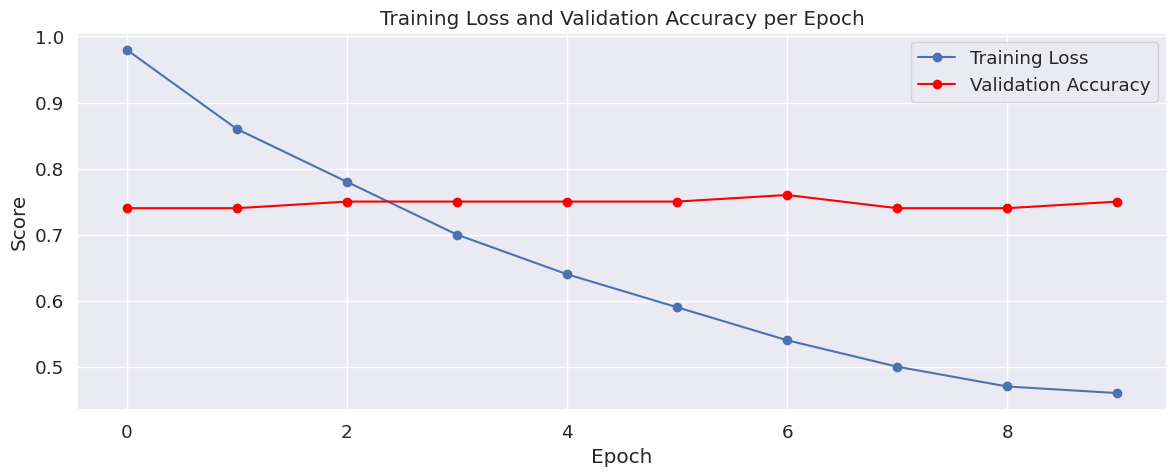

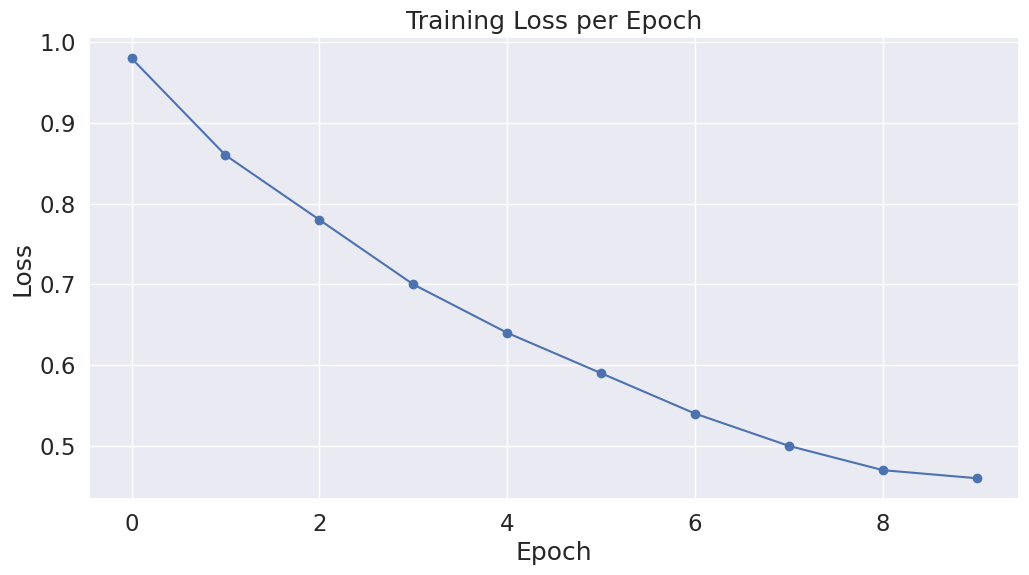

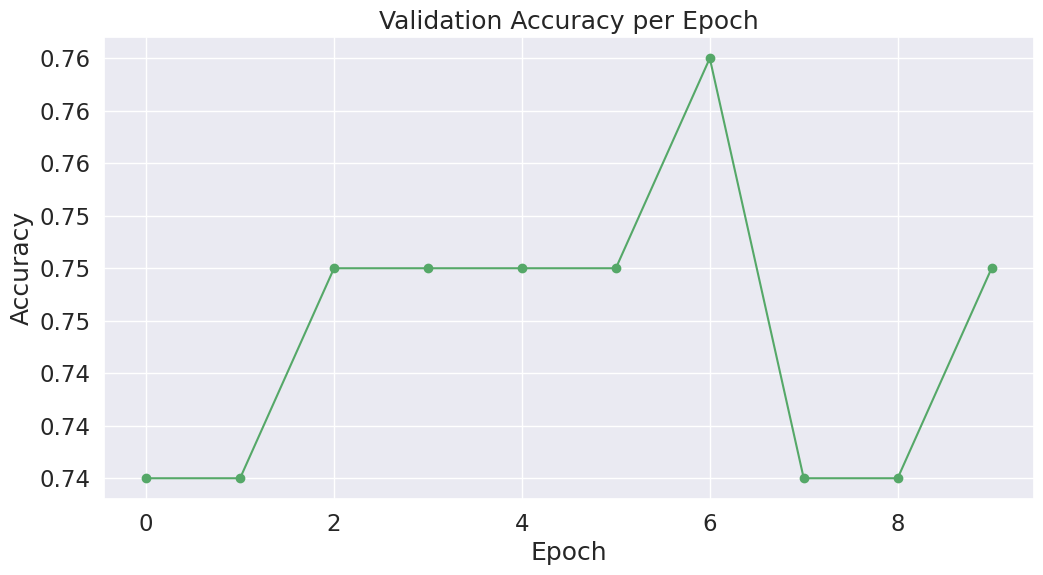

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

# Data hasil training
train_losses = [0.98, 0.86, 0.78, 0.70, 0.64, 0.59, 0.54, 0.50, 0.47, 0.46]
val_accuracies = [0.74, 0.74, 0.75, 0.75, 0.75, 0.75, 0.76, 0.74, 0.74, 0.75]

# --- Plot Gabungan (sudah benar) ---
sns.set(style='darkgrid')
sns.set(font_scale=1.2)
plt.rcParams["figure.figsize"] = (12, 5)

plt.plot(train_losses, 'b-o', label='Training Loss')
plt.plot(val_accuracies, 'red', marker='o', label='Validation Accuracy')

plt.title("Training Loss and Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()


# --- Plot Terpisah (perbaikan) ---
# Plot Training Loss
sns.set(style='darkgrid')
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12, 6)

plt.plot(train_losses, 'b-o')
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Plot Validation Accuracy
sns.set(style='darkgrid')
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12, 6)

plt.plot(val_accuracies, 'g-o')
plt.title("Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

# Mengatur format sumbu Y menjadi 3 digit desimal
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

plt.show()

In [27]:
print("Memprediksi label untuk {:,} kalimat test".format(len(test_input)))


model.eval() # Mengatur model ke mode evaluasi


prediction, true_labels = [], [] # List untuk menyimpan hasil prediksi dan label sebenarnya


# Loop melalui setiap batch dalam test data
for batch in test_dataloader:
  # Memindahkan batch ke GPU
  batch = tuple(t.to(device) for t in batch)
  b_input_ids, b_input_mask, b_labels = batch


  with torch.no_grad(): # Menonaktifkan perhitungan gradien selama prediksi
    # Melakukan forward pass
    outputs = model(b_input_ids,
                    token_type_ids=None,
                    attention_mask=b_input_mask)


  logits = outputs[0] # Mengambil logits dari output


  logits = logits.detach().cpu().numpy() # Memindahkan logits ke CPU dan mengubah menjadi numpy array
  label_ids = b_labels.to('cpu').numpy() # Memindahkan label ke CPU dan mengubah menjadi numpy array


  prediction.append(logits) # Menyimpan logits prediksi
  true_labels.append(label_ids) # Menyimpan label sebenarnya


print(" Selesai.")



Memprediksi label untuk 198 kalimat test
 Selesai.


In [28]:
from sklearn.metrics import matthews_corrcoef
import numpy as np


# Meratakan hasil prediksi dan label sebenarnya
flat_prediction = [item for sublist in prediction for item in sublist]
flat_prediction = np.argmax(flat_prediction, axis=1).flatten()


flat_true_labels = [item for sublist in true_labels for item in sublist]


# Menghitung Matthews Correlation Coefficient (MCC)
mcc = matthews_corrcoef(flat_true_labels, flat_prediction)


print("MCC: %.3f" %mcc)


MCC: 0.307


In [29]:
from sklearn.metrics import accuracy_score


# Menghitung Akurasi
acc = accuracy_score(flat_true_labels, flat_prediction)


print("ACC: %.3f" %acc)


ACC: 0.717


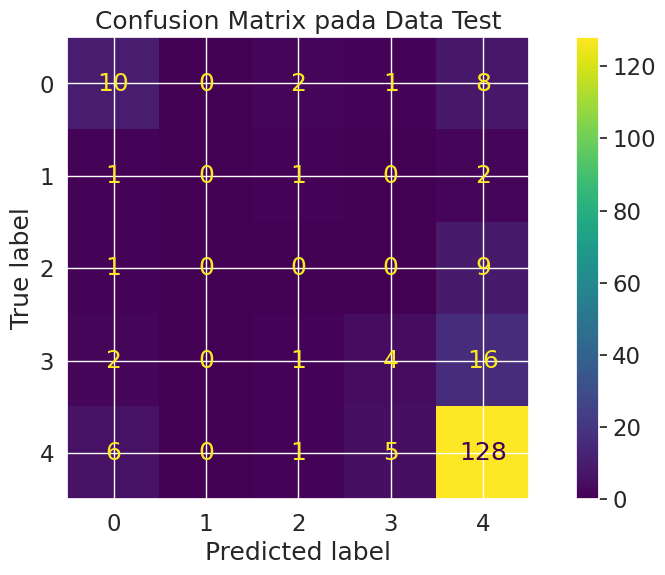

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Menghitung confusion matrix
cm = confusion_matrix(flat_true_labels, flat_prediction)


# Membuat objek ConfusionMatrixDisplay
cmd = ConfusionMatrixDisplay(confusion_matrix=cm)


# Menggambar confusion matrix
cmd.plot()


# Menambahkan judul ke plot
plt.title("Confusion Matrix pada Data Test")


# Menampilkan plot
plt.show()



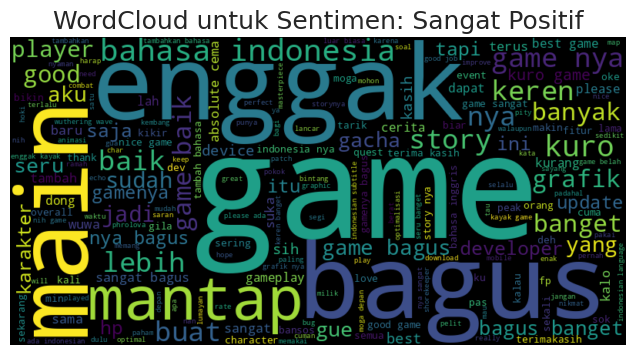

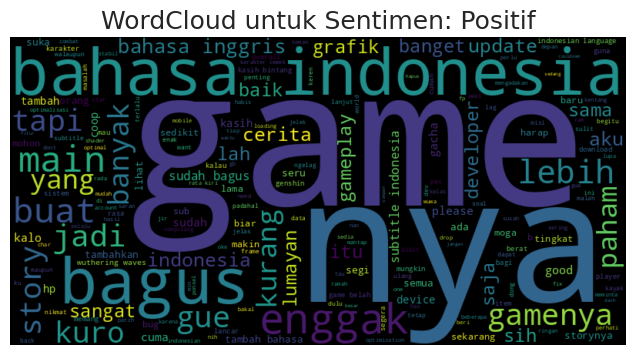

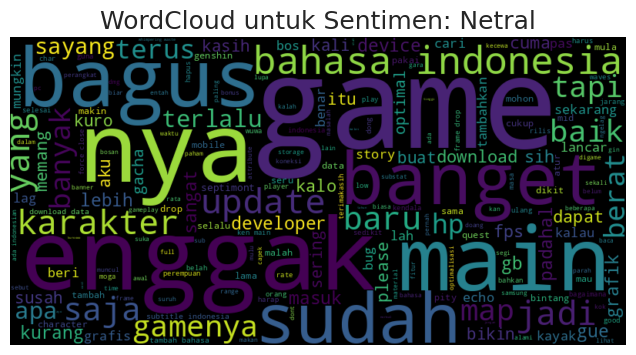

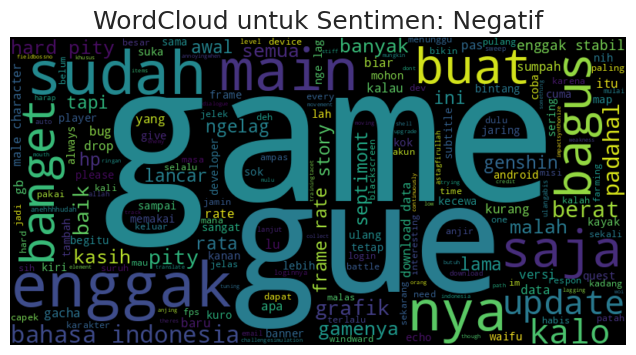

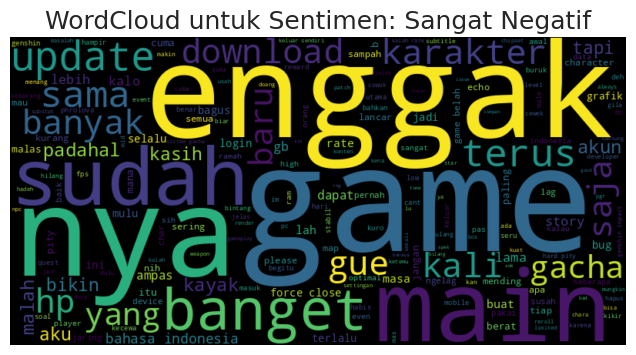

In [34]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Pakai kolom sesuai dataset
sentiment_col = "sentimen"
text_col = "normalized_text"

# Mapping kategori (kalau beda huruf besar/kecil, kita normalisasi dulu)
mapping_kategori = {
    "sangat positif": "Sangat Positif",
    "positif": "Positif",
    "netral": "Netral",
    "negatif": "Negatif",
    "sangat negatif": "Sangat Negatif"
}

# Normalisasi isi kolom sentimen ke bentuk konsisten
df[sentiment_col] = df[sentiment_col].str.lower().map(mapping_kategori)

# Buat wordcloud per kategori
for kategori in mapping_kategori.values():
    teks = " ".join(df[df[sentiment_col] == kategori][text_col].astype(str))

    if teks.strip():  # hanya kalau ada datanya
        wc = WordCloud(width=800, height=400, background_color="black").generate(teks)

        plt.figure(figsize=(8, 4))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(f"WordCloud untuk Sentimen: {kategori}")
        plt.show()
    else:
        print(f"⚠️ Tidak ada data untuk kategori: {kategori}")


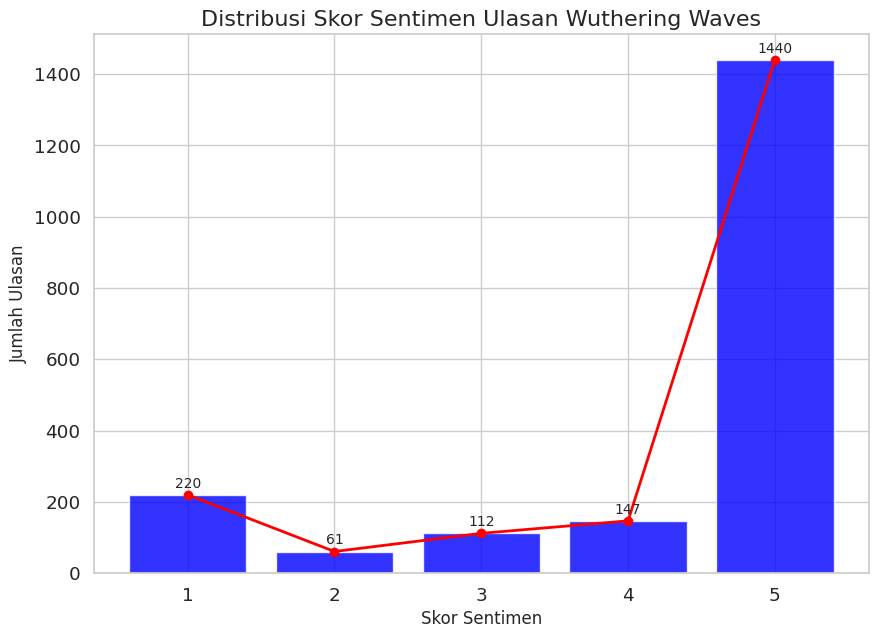

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Hitung distribusi score (urut 1-5)
score_counts = df['score'].value_counts().reindex([1,2,3,4,5], fill_value=0)


# Set style dan ukuran
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 7)


# Buat barplot dengan matplotlib agar x tetap presisi
plt.bar(score_counts.index, score_counts.values, color="blue", alpha=0.8)


# Tambahkan garis kurva di atas bar
plt.plot(score_counts.index, score_counts.values,
         marker="o", color="red", linewidth=2)


# Tambahkan judul dan label
plt.title("Distribusi Skor Sentimen Ulasan Wuthering Waves", fontsize=16)
plt.xlabel("Skor Sentimen", fontsize=12)
plt.ylabel("Jumlah Ulasan", fontsize=12)


# Tambahkan label jumlah di atas bar
for i, v in enumerate(score_counts.values, start=1):
    plt.text(i, v + 20, str(v), ha='center', fontsize=10)


plt.xticks([1,2,3,4,5])  # pastikan sumbu x dari 1–5
plt.show()



In [40]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Langkah 1: Gunakan model yang sudah dilatih untuk membuat prediksi
# Ganti 'model' dengan nama objek model Anda (misalnya: svm_model, rfc_model, dnn_model)
# Ganti 'X_test' dengan fitur dari data uji Anda
# y_pred = model.predict(X_test) # This line caused the error.

# Instead, we will use the results from the prediction loop in cell II1hetI5C--t
# The predictions are already stored in the 'prediction' variable and true labels in 'true_labels'.

# Flatten the predictions and true labels
flat_prediction = [item for sublist in prediction for item in sublist]
flat_prediction = np.argmax(flat_prediction, axis=1).flatten()

flat_true_labels = [item for sublist in true_labels for item in sublist]


# Langkah 2: Hitung metrik evaluasi
# Akurasi
accuracy = accuracy_score(flat_true_labels, flat_prediction)
print(f"Accuracy: {accuracy:.4f}")

# Presisi (rata-rata over classes)
# Menggunakan zero_division=0 untuk menghindari warning jika ada kelas yang tidak memiliki prediksi
precision = precision_score(flat_true_labels, flat_prediction, average='weighted', zero_division=0)
print(f"Precision (weighted): {precision:.4f}")

# Recall (rata-rata over classes)
recall = recall_score(flat_true_labels, flat_prediction, average='weighted', zero_division=0)
print(f"Recall (weighted): {recall:.4f}")

# F1-Score (rata-rata over classes)
f1 = f1_score(flat_true_labels, flat_prediction, average='weighted', zero_division=0)
print(f"F1-Score (weighted): {f1:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(flat_true_labels, flat_prediction, zero_division=0))

# Confusion Matrix (sudah ada di cell berikutnya, tapi bisa diulang di sini kalau mau)
# print("\nConfusion Matrix:")
# cm = confusion_matrix(flat_true_labels, flat_prediction)
# print(cm)

# Plot Confusion Matrix (sudah ada di cell berikutnya, tapi bisa diulang di sini kalau mau)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
# plt.xlabel('Predicted Label')
# plt.ylabel('True Label')
# plt.title('Confusion Matrix')
# plt.show()

Accuracy: 0.7172
Precision (weighted): 0.6547
Recall (weighted): 0.7172
F1-Score (weighted): 0.6773

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.48      0.49        21
           1       0.00      0.00      0.00         4
           2       0.00      0.00      0.00        10
           3       0.40      0.17      0.24        23
           4       0.79      0.91      0.84       140

    accuracy                           0.72       198
   macro avg       0.34      0.31      0.32       198
weighted avg       0.65      0.72      0.68       198

